![pandas logo](http://drive.google.com/uc?export=view&id=1a2QGwlq1iltY7-9T0b07JZxaEBkL_xG_)

# Pandas
* 컬럼의 이름을 따라 데이터를 정렬할 수 있는 자료 구조(data structure). 

* 다양한 소스에서 가져온 다양한 방식으로 색인된 데이터를 핸들링 가능한 기능


* 시계열, 비시계열 데이터 모두 다룰 수 있는 자료 구조

* 산술연산 및 한 축(column을 의미하는 듯)의 모든 값을 더하는 등의 축약연산이 가능

* 누락된 데이터의 유연한 처리 기능

* SQL 같은 관계연산 수행 기능

## Series
* 1차원 배열과 같은구조
* 값을 저장하는 value와 색인를 저장하는 index로 구성
* 동일한 종류의 자료를 저장

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
s = pd.Series(np.random.randn(5))
print(s)

0    1.590360
1   -0.493137
2   -1.177906
3   -0.288245
4    0.617867
dtype: float64


In [ ]:
s = pd.Series(np.random.randn(5), 
              index=['a', 'b', 'c', 'd', 'e'])
print(s)

a   -0.515061
b   -0.117511
c    1.140103
d    0.369413
e    0.106064
dtype: float64


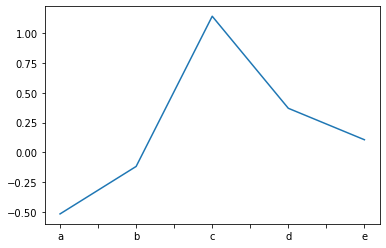

In [ ]:
s.plot()

In [ ]:
s.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

In [ ]:
s.values

array([-0.51506082, -0.11751113,  1.14010322,  0.36941283,  0.1060636 ])

In [ ]:
dic = {'a': 0, 'b': 1,  'c': 2}
series1 = pd.Series(dic)

In [ ]:
pd.Series(dic, index=['b', 'c', 'd', 'a'])

b    1.0
c    2.0
d    NaN
a    0.0
dtype: float64

* NaN (not a number) 결측치 - 값이 없거나 형식이 안맞는 경우


In [ ]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
print(s)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64


In [ ]:
dates = pd.date_range('20210330', periods=6)
print(dates)

DatetimeIndex(['2021-03-30', '2021-03-31', '2021-04-01', '2021-04-02',
               '2021-04-03', '2021-04-04'],
              dtype='datetime64[ns]', freq='D')


## DataFrame

* 엑셀과 같이 여러가지의 데이터가 모인 자료구조
* 여러개의 Series가 모인 자료구조

In [ ]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, 
                  columns=list('ABCD'))
print(df)

                   A         B         C         D
2013-01-01  0.474190  0.253030  1.163523  1.072972
2013-01-02 -0.061099 -0.293044  0.227052 -1.249082
2013-01-03  0.642035 -1.528227 -0.001745  0.480744
2013-01-04  0.183614  0.221681 -0.667302  0.579064
2013-01-05 -0.407336  1.862459  0.131273  1.141309
2013-01-06 -0.804822  2.336836 -1.742707 -2.012518


In [ ]:
df2 = pd.DataFrame({'A': 1.,
                    'B': pd.Timestamp('20130102'),
                    'C': pd.Series(1, index=list(range(4)), dtype='float32'),
                    'D': np.array([3]*4, dtype='int32'),
                    'E':['test', 'train', 'test', 'train'],
                    'F': 'foo'})
print(df2)

     A          B    C  D      E    F
0  1.0 2013-01-02  1.0  3   test  foo
1  1.0 2013-01-02  1.0  3  train  foo
2  1.0 2013-01-02  1.0  3   test  foo
3  1.0 2013-01-02  1.0  3  train  foo


In [ ]:
df2.dtypes

A           float64
B    datetime64[ns]
C           float32
D             int32
E            object
F            object
dtype: object

### 데이터 확인하기

####  df.head()
 * 처음 5개 데이터 표시
 
#### df.head(n)
* 처음 n개 데이터 표시

In [ ]:
df.head()

,A,B,C,D
2013-01-01,0.474190,0.253030,1.163523,1.072972
2013-01-02,-0.061099,-0.293044,0.227052,-1.249082
2013-01-03,0.642035,-1.528227,-0.001745,0.480744
2013-01-04,0.183614,0.221681,-0.667302,0.579064
2013-01-05,-0.407336,1.862459,0.131273,1.141309


#### df.tail()
* 마지막 5개 데이터 표시

#### df.tail(n)
* 마지막 n개 데이터 표시

In [ ]:
df.tail(3)

,A,B,C,D
2013-01-04,0.183614,0.221681,-0.667302,0.579064
2013-01-05,-0.407336,1.862459,0.131273,1.141309
2013-01-06,-0.804822,2.336836,-1.742707,-2.012518


#### df.index
* DataFrame의 인덱스를 추출
* 함수가 아니고 속성임

* 컬럼을 보려면 .columns 속성
* numpy 데이터를 보려면 .values 속성을 통해 확인하면 됩니다.

In [ ]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

#### df.colums
* DataFrame의 컬럼들을 추출
* 함수가 아니고 속성임

In [ ]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

#### df.values
* DataFrame의 value를 추출
* 함수가 아니고 속성임

In [ ]:
df.values

array([[ 4.74189727e-01,  2.53030392e-01,  1.16352325e+00,
         1.07297195e+00],
       [-6.10992813e-02, -2.93043755e-01,  2.27051797e-01,
        -1.24908161e+00],
       [ 6.42034719e-01, -1.52822731e+00, -1.74516452e-03,
         4.80743639e-01],
       [ 1.83614361e-01,  2.21680955e-01, -6.67301806e-01,
         5.79064277e-01],
       [-4.07336251e-01,  1.86245902e+00,  1.31272688e-01,
         1.14130853e+00],
       [-8.04822270e-01,  2.33683648e+00, -1.74270687e+00,
        -2.01251801e+00]])

#### df.describe()
 DataFrame의 요약된 통계 정보를 보여줌

In [ ]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.004430,0.475456,-0.148318,0.002081
std,0.545537,1.421811,0.977027,1.313826
min,-0.804822,-1.528227,-1.742707,-2.012518
25%,-0.320777,-0.164363,-0.500913,-0.816625
50%,0.061258,0.237356,0.064764,0.529904
75%,0.401546,1.460102,0.203107,0.949495
max,0.642035,2.336836,1.163523,1.141309


#### df .T 
* DataFrame에서 index와 column을 바꾼 형태의 DataFrame 
* 속성

In [ ]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,0.474190,-0.061099,0.642035,0.183614,-0.407336,-0.804822
B,0.253030,-0.293044,-1.528227,0.221681,1.862459,2.336836
C,1.163523,0.227052,-0.001745,-0.667302,0.131273,-1.742707
D,1.072972,-1.249082,0.480744,0.579064,1.141309,-2.012518


#### df.sort_index()
* axis = 0 : index를 기준으로 정렬
* axis = 1 : column을 기준으로 정렬
* ascending = True : 오름차순
* ascending = Fals : 내림차순

In [ ]:
df.sort_index(axis=0, ascending=True)

,A,B,C,D
2013-01-01,0.474190,0.253030,1.163523,1.072972
2013-01-02,-0.061099,-0.293044,0.227052,-1.249082
2013-01-03,0.642035,-1.528227,-0.001745,0.480744
2013-01-04,0.183614,0.221681,-0.667302,0.579064
2013-01-05,-0.407336,1.862459,0.131273,1.141309
2013-01-06,-0.804822,2.336836,-1.742707,-2.012518


In [ ]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,1.072972,1.163523,0.253030,0.474190
2013-01-02,-1.249082,0.227052,-0.293044,-0.061099
2013-01-03,0.480744,-0.001745,-1.528227,0.642035
2013-01-04,0.579064,-0.667302,0.221681,0.183614
2013-01-05,1.141309,0.131273,1.862459,-0.407336
2013-01-06,-2.012518,-1.742707,2.336836,-0.804822


### 데이터 선택하기 (Selection)

In [ ]:
print(df['A'])
type(df['A'])


2013-01-01    0.474190
2013-01-02   -0.061099
2013-01-03    0.642035
2013-01-04    0.183614
2013-01-05   -0.407336
2013-01-06   -0.804822
Freq: D, Name: A, dtype: float64


pandas.core.series.Series

In [ ]:
df[0:3]

,A,B,C,D
2013-01-01,0.474190,0.253030,1.163523,1.072972
2013-01-02,-0.061099,-0.293044,0.227052,-1.249082
2013-01-03,0.642035,-1.528227,-0.001745,0.480744


In [ ]:
df['20130102':'20130104']

,A,B,C,D
2013-01-02,-0.061099,-0.293044,0.227052,-1.249082
2013-01-03,0.642035,-1.528227,-0.001745,0.480744
2013-01-04,0.183614,0.221681,-0.667302,0.579064


In [ ]:
df.iloc[3]

A    0.183614
B    0.221681
C   -0.667302
D    0.579064
Name: 2013-01-04 00:00:00, dtype: float64

In [ ]:
df.iloc[3:5,0:2]

,A,B
2013-01-04,0.183614,0.221681
2013-01-05,-0.407336,1.862459


In [ ]:
df.iloc[[1,2,4],[0,2]]

,A,C
2013-01-02,-0.061099,0.227052
2013-01-03,0.642035,-0.001745
2013-01-05,-0.407336,0.131273


In [ ]:
df.iloc[1:3,:]

,A,B,C,D
2013-01-02,-0.061099,-0.293044,0.227052,-1.249082
2013-01-03,0.642035,-1.528227,-0.001745,0.480744


### 조건을 이용하여 선택하기

In [ ]:
print(df)
df[(df.B > 0) & (df.C > 0)]

                   A         B         C         D
2013-01-01  0.474190  0.253030  1.163523  1.072972
2013-01-02 -0.061099 -0.293044  0.227052 -1.249082
2013-01-03  0.642035 -1.528227 -0.001745  0.480744
2013-01-04  0.183614  0.221681 -0.667302  0.579064
2013-01-05 -0.407336  1.862459  0.131273  1.141309
2013-01-06 -0.804822  2.336836 -1.742707 -2.012518


,A,B,C,D
2013-01-01,0.474190,0.253030,1.163523,1.072972
2013-01-05,-0.407336,1.862459,0.131273,1.141309


### 연산



#### mean() 
* 평균구하기
* 컬럼별로 평균

In [ ]:
df.mean()

A    0.004430
B    0.475456
C   -0.148318
D    0.002081
dtype: float64

#### mean(1)
* index 기준으로 평균

In [ ]:
df.mean(1)

2013-01-01    0.740929
2013-01-02   -0.344043
2013-01-03   -0.101799
2013-01-04    0.079264
2013-01-05    0.681926
2013-01-06   -0.555803
Freq: D, dtype: float64

### 데이터 합치기
 
 

#### concat

In [ ]:
df = pd.DataFrame(np.random.randn(10, 4), columns=list('ABCD'))
print(df)

          A         B         C         D
0  0.354986  0.863332  0.041963 -0.544410
1 -0.545674 -0.690660 -1.191672 -0.113046
2  0.293363 -1.662926 -0.369296 -0.729072
3  0.136863  1.768132 -1.022237  1.332731
4 -0.638237  0.849602  0.327428  2.390691
5  0.121685  0.284635 -0.384042 -0.330857
6  1.886688 -0.855979  1.123483 -2.204001
7  0.054172  0.000312 -0.049125 -0.397748
8  0.372643 -1.562467  0.255682  0.033271
9  2.092507  0.297880  0.296612 -0.560500


In [ ]:
pieces = [df[:3], df[3:7], df[7:]]
print(pieces[0])
print(pieces[1])
print(pieces[2])

          A         B         C         D
0  0.354986  0.863332  0.041963 -0.544410
1 -0.545674 -0.690660 -1.191672 -0.113046
2  0.293363 -1.662926 -0.369296 -0.729072
          A         B         C         D
3  0.136863  1.768132 -1.022237  1.332731
4 -0.638237  0.849602  0.327428  2.390691
5  0.121685  0.284635 -0.384042 -0.330857
6  1.886688 -0.855979  1.123483 -2.204001
          A         B         C         D
7  0.054172  0.000312 -0.049125 -0.397748
8  0.372643 -1.562467  0.255682  0.033271
9  2.092507  0.297880  0.296612 -0.560500


In [ ]:
pd.concat(pieces)

,A,B,C,D
0,0.354986,0.863332,0.041963,-0.544410
1,-0.545674,-0.690660,-1.191672,-0.113046
2,0.293363,-1.662926,-0.369296,-0.729072
3,0.136863,1.768132,-1.022237,1.332731
4,-0.638237,0.849602,0.327428,2.390691
5,0.121685,0.284635,-0.384042,-0.330857
6,1.886688,-0.855979,1.123483,-2.204001
7,0.054172,0.000312,-0.049125,-0.397748
8,0.372643,-1.562467,0.255682,0.033271
9,2.092507,0.297880,0.296612,-0.560500


#### join

In [ ]:
left = pd.DataFrame({'key': ['foo', 'foo'], 'lval': [1, 2]})
print(left)

   key  lval
0  foo     1
1  foo     2


In [ ]:
right = pd.DataFrame({'key': ['foo', 'foo'], 'rval': [4, 5]})
print(right)

   key  rval
0  foo     4
1  foo     5


In [ ]:
merged = pd.merge(left, right, on='key')
print(merged)

   key  lval  rval
0  foo     1     4
1  foo     1     5
2  foo     2     4
3  foo     2     5


In [ ]:
df = pd.DataFrame(np.random.randn(8, 4), columns=['A', 'B', 'C', 'D'])
s = df.iloc[3]
df.append(s, ignore_index=True)

,A,B,C,D
0,0.452164,0.829410,-0.323257,-0.483392
1,1.482611,-1.536430,1.116847,-2.019355
2,-0.353789,-0.439300,0.553105,-0.145844
3,1.237560,-0.736766,-1.715813,-0.197868
4,-0.529103,-1.076287,-0.107270,0.298741
5,0.001701,-0.222339,1.370618,0.873873
6,-0.813998,-1.624283,-0.170622,-1.021837
7,-0.451168,-0.396537,2.208418,-0.815483
8,1.237560,-0.736766,-1.715813,-0.197868


### 범주형

In [ ]:
df2 = pd.DataFrame({"id": [1, 2, 3, 4, 5, 6],
                   "raw_grade": ['a', 'b', 'b', 'a', 'a', 'e']})
df2

,id,raw_grade
0,1,a
1,2,b
2,3,b
3,4,a
4,5,a
5,6,e


In [ ]:
df2['grade'] = df2['raw_grade'].astype('category')
df2['grade']

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, object): ['a', 'b', 'e']

In [ ]:
df2['grade'].cat.categories = ['very good', 'good', 'very bad']
df2['grade']


0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (3, object): ['very good', 'good', 'very bad']

In [ ]:
df2["grade"].cat.set_categories(["very good", "good", "very bad"])
print(df2['grade'])

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (3, object): ['very good', 'good', 'very bad']
